# Portfolio attribution versus the Russell 1000 Growth

**Leland Degas Wright · Atlanta, GA · cache dated 9 October 2026**

A 14-stock U.S. large-cap growth book: at each quarter-end, the two largest companies in each sector of a fixed 77-name coverage list, equal-weighted. The question is how much of its return gap versus IWF, the iShares Russell 1000 Growth ETF, is sector weights, stock selection inside those sectors, and a handful of style-factor ETF spreads.

This notebook is an educational exercise for interview practice. It is not a recommendation to buy or sell any security.

The calculations live in `attribution.py`. This notebook runs that pipeline from the cached CSV files (no network), then shows the tables, the SQL, and the charts. Figures below match `README.md` for this cache. The one-page note is `MEMO.md`.


## 1. Question

For a simple large-cap growth book, measured against the Russell 1000 Growth:

1. Did the sector weights differ from a cap-weighted book of the same names, and did those sectors then lead or lag?
2. Inside a sector, did the names in the book do better than the cap-weighted sector?
3. Does the gap versus IWF look like value, size, momentum, or quality?

Free data has no history of Russell 1000 Growth membership. Holdings-based attribution is against a cap-weighted portfolio of the same 77 names. IWF is the external benchmark. The gap between that cap-weighted portfolio and IWF is reported on its own.


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

import attribution as attr

summary = attr.run(force_download=False)
quality = summary["quality"]
print("Cache date:", quality["asof"])
print(
    f"Quarters: {quality['n_quarters']}  "
    f"{quality['first_rebalance']} -> {quality['last_month']}"
)
print(
    "Market-cap check vs Yahoo: median "
    f"{quality['median_mcap_ratio_vs_yahoo']:.3f}, "
    f"range {quality['min_mcap_ratio_vs_yahoo']:.3f} to {quality['max_mcap_ratio_vs_yahoo']:.3f}"
)
print("Names on the price-scaled fallback:", quality["n_price_scaled_fallback"])


Using cached raw files in data/raw/


{
  "quality": {
    "asof": "2026-10-09",
    "n_universe": 77,
    "n_sectors": 7,
    "sectors": [
      "Communication Services",
      "Consumer Cyclical",
      "Consumer Defensive",
      "Financial Services",
      "Healthcare",
      "Industrials",
      "Technology"
    ],
    "n_quarters": 20,
    "first_rebalance": "2021-09-30",
    "last_rebalance": "2026-06-30",
    "last_month": "2026-09-30",
    "n_price_scaled_fallback": 0,
    "fallback_tickers": [],
    "n_months_with_share_factor": 1196,
    "n_months_with_spinoff_factor": 323,
    "median_mcap_ratio_vs_yahoo": 0.9870172411221169,
    "min_mcap_ratio_vs_yahoo": 0.8738121637279087,
    "max_mcap_ratio_vs_yahoo": 1.0458388396997809
  },
  "performance": [
    {
      "portfolio": "Sector-pair",
      "months": 60,
      "quarters": 20,
      "cagr": 0.20753068673464714,
      "ann_vol": 0.16444885068793225,
      "sharpe_rf0": 1.2357385733206343,
      "sharpe_bil": 1.0234119724470023,
      "max_drawdown": -0.1991382

## 2. Performance

Monthly wealth, total return, from the 30 September 2021 rebalance through 30 September 2026. CAGR, volatility, and the drawdown use that monthly curve. Sharpe (rf = 0) uses a zero cash rate, so it can be set next to the earnings-revision project. Sharpe (BIL) subtracts the monthly return of a 1–3 month T-bill ETF. BIL is an ETF, not the T-bill index.

The two universe CAGRs both round to 17.9%. The total-return column keeps them distinct.


In [2]:
perf = pd.read_csv("data/performance_stats.csv")
show = perf.copy()
pct_cols = [
    "cagr",
    "ann_vol",
    "max_drawdown",
    "hit_rate_positive",
    "hit_rate_vs_iwf",
    "avg_quarter_return",
    "total_return",
]
for col in pct_cols:
    show[col] = (show[col] * 100).round(1)
show["sharpe_rf0"] = show["sharpe_rf0"].round(2)
show["sharpe_bil"] = show["sharpe_bil"].round(2)
show = show.rename(
    columns={
        "portfolio": "Portfolio",
        "cagr": "CAGR %",
        "ann_vol": "Vol %",
        "sharpe_rf0": "Sharpe rf=0",
        "sharpe_bil": "Sharpe BIL",
        "max_drawdown": "Max DD %",
        "hit_rate_positive": "Quarters up %",
        "hit_rate_vs_iwf": "Beat IWF %",
        "avg_quarter_return": "Avg quarter %",
        "total_return": "Total %",
    }
)
show[
    [
        "Portfolio",
        "CAGR %",
        "Vol %",
        "Sharpe rf=0",
        "Sharpe BIL",
        "Max DD %",
        "Quarters up %",
        "Beat IWF %",
        "Avg quarter %",
        "Total %",
    ]
]


,Portfolio,CAGR %,Vol %,Sharpe rf=0,Sharpe BIL,Max DD %,Quarters up %,Beat IWF %,Avg quarter %,Total %
0,Sector-pair,20.8,16.4,1.24,1.02,-19.9,70.0,70.0,5.2,156.7
1,Cap-weight universe,17.9,19.4,0.95,0.77,-27.7,70.0,80.0,4.7,127.3
2,Equal-weight universe,17.9,17.9,1.02,0.82,-26.0,70.0,70.0,4.6,128.1
3,IWF,13.5,19.3,0.75,0.57,-30.7,70.0,NaN,3.8,88.2


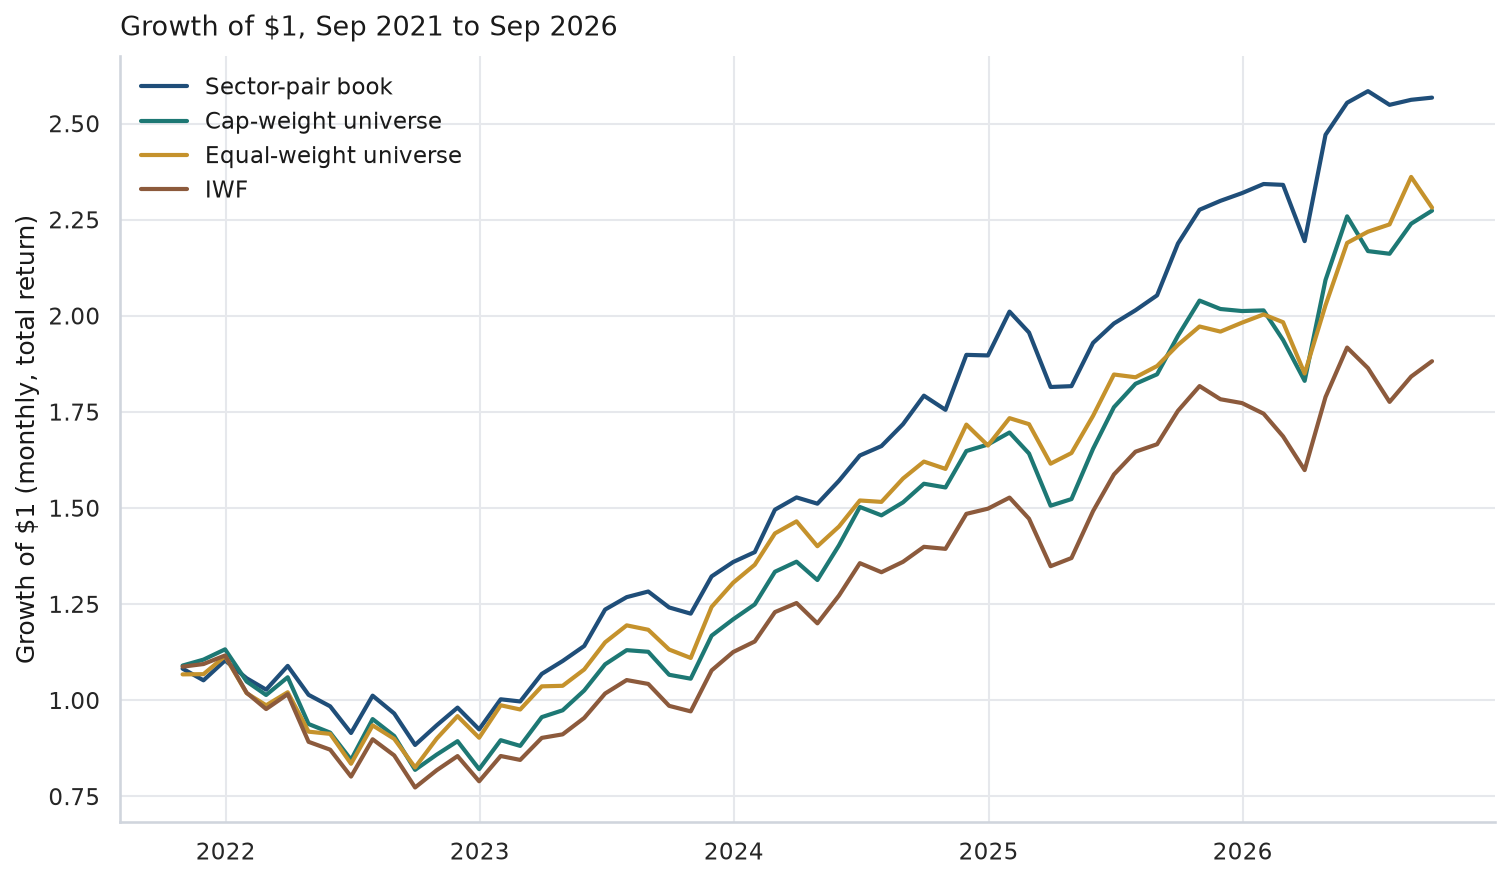

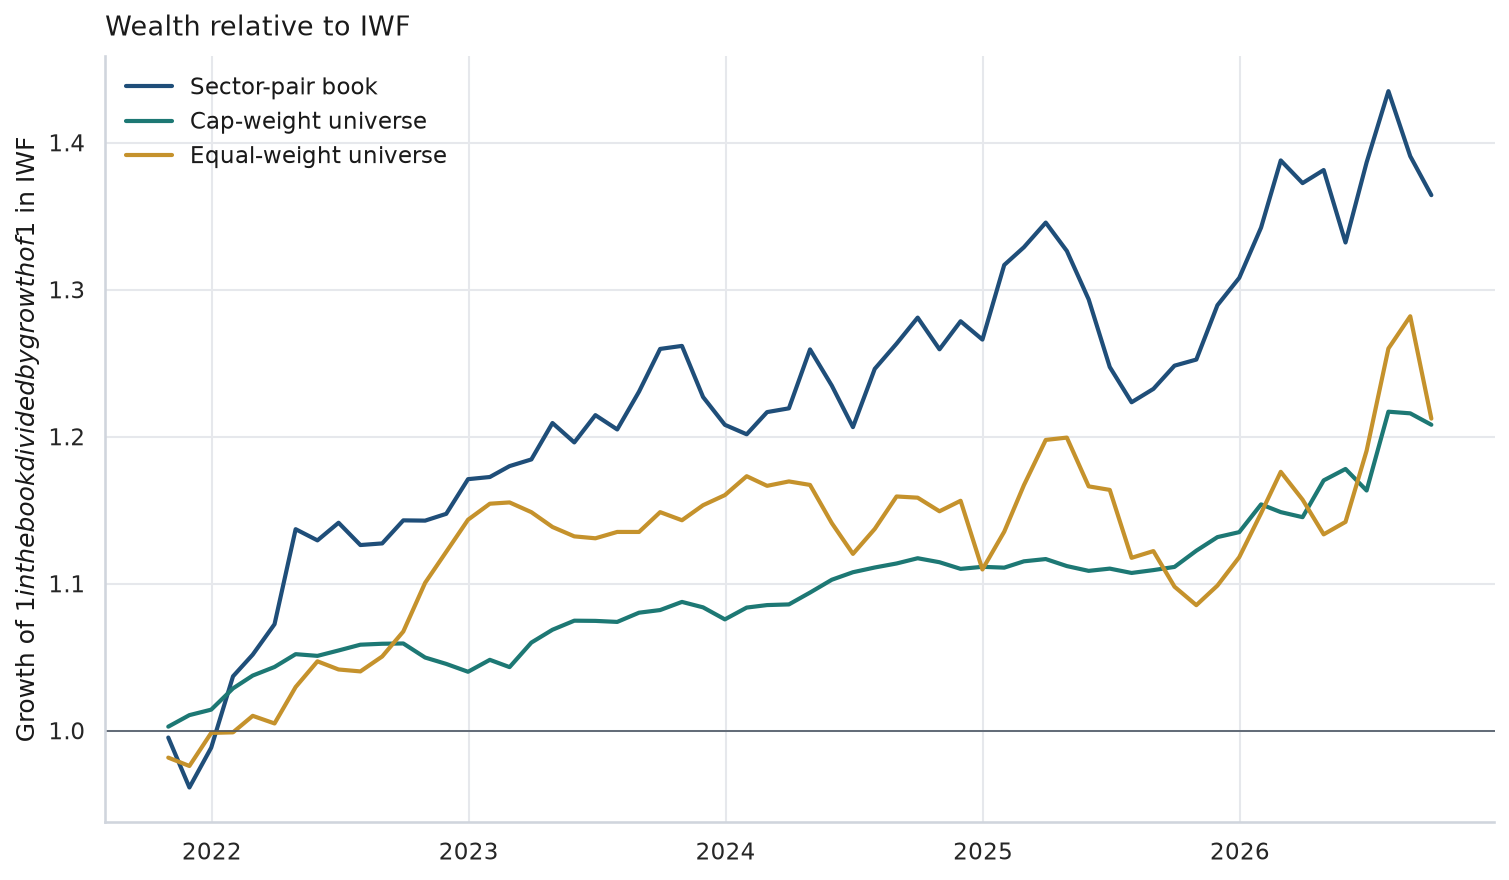

In [3]:
display(Image("images/01_growth_of_one.png"))
display(Image("images/02_relative_wealth.png"))


## 3. Holdings and the Brinson identity

The SQL below is the same database the script writes. The first query lists who was held. The second recomputes the quarterly gap from the stored returns, so the excess column can be checked rather than trusted. The third reads the Carino-linked sector table. A plain average of the quarterly allocation effects is not the linked number. The notebook prints both.


In [4]:
held = attr.run_sql(
    """
    SELECT ticker,
           sector,
           SUM(selected) AS quarters_held,
           MIN(CASE WHEN selected = 1 THEN rebalance_date END) AS first_held,
           MAX(CASE WHEN selected = 1 THEN rebalance_date END) AS last_held
    FROM holdings
    GROUP BY ticker, sector
    HAVING quarters_held > 0
    ORDER BY sector, quarters_held DESC, ticker
    """
)
held


,ticker,sector,quarters_held,first_held,last_held
0,GOOGL,Communication Services,20,2021-09-30 00:00:00,2026-06-30 00:00:00
1,META,Communication Services,17,2022-06-30 00:00:00,2026-06-30 00:00:00
2,DIS,Communication Services,3,2021-09-30 00:00:00,2022-03-31 00:00:00
3,AMZN,Consumer Cyclical,20,2021-09-30 00:00:00,2026-06-30 00:00:00
4,TSLA,Consumer Cyclical,20,2021-09-30 00:00:00,2026-06-30 00:00:00
5,WMT,Consumer Defensive,20,2021-09-30 00:00:00,2026-06-30 00:00:00
6,PG,Consumer Defensive,13,2021-09-30 00:00:00,2024-09-30 00:00:00
7,COST,Consumer Defensive,7,2024-12-31 00:00:00,2026-06-30 00:00:00
8,MA,Financial Services,20,2021-09-30 00:00:00,2026-06-30 00:00:00
9,V,Financial Services,20,2021-09-30 00:00:00,2026-06-30 00:00:00


In [5]:
gaps = attr.run_sql(
    """
    SELECT rebalance_date,
           ROUND(ret_port, 4) AS ret_port,
           ROUND(ret_bench, 4) AS ret_bench,
           ROUND(ret_iwf, 4) AS ret_iwf,
           ROUND(ret_port - ret_bench, 4) AS excess_vs_bench,
           ROUND(ret_port - ret_iwf, 4) AS excess_vs_iwf,
           ROUND(allocation + selection + interaction, 4) AS brinson_sum,
           ROUND((allocation + selection + interaction) - (ret_port - ret_bench), 6) AS identity_gap
    FROM quarterly_returns
    ORDER BY rebalance_date
    """
)
print("Largest absolute identity gap:", gaps["identity_gap"].abs().max())
gaps


Largest absolute identity gap: 0.0


,rebalance_date,ret_port,ret_bench,ret_iwf,excess_vs_bench,excess_vs_iwf,brinson_sum,identity_gap
0,2021-09-30 00:00:00,0.1036,0.1325,0.1166,-0.0289,-0.0130,-0.0289,0.0
1,2021-12-31 00:00:00,-0.0128,-0.0641,-0.0901,0.0513,0.0773,0.0513,-0.0
2,2022-03-31 00:00:00,-0.1602,-0.2025,-0.2110,0.0423,0.0508,0.0423,-0.0
3,2022-06-30 00:00:00,-0.0340,-0.0310,-0.0354,-0.0030,0.0014,-0.0030,0.0
4,2022-09-30 00:00:00,0.0459,0.0023,0.0208,0.0436,0.0250,0.0436,0.0
5,2022-12-31 00:00:00,0.1561,0.1648,0.1430,-0.0087,0.0131,-0.0087,0.0
6,2023-03-31 00:00:00,0.1566,0.1436,0.1279,0.0130,0.0287,0.0130,0.0
7,2023-06-30 00:00:00,0.0044,-0.0249,-0.0315,0.0293,0.0359,0.0293,0.0
8,2023-09-30 00:00:00,0.0952,0.1354,0.1420,-0.0401,-0.0468,-0.0401,-0.0
9,2023-12-31 00:00:00,0.1235,0.1237,0.1132,-0.0002,0.0103,-0.0002,-0.0


In [6]:
linked = attr.run_sql(
    """
    SELECT sector,
           ROUND(avg_w_port, 3) AS avg_w_port,
           ROUND(avg_w_bench, 3) AS avg_w_bench,
           ROUND(linked_allocation, 3) AS linked_allocation,
           ROUND(linked_selection, 3) AS linked_selection,
           ROUND(linked_interaction, 3) AS linked_interaction,
           ROUND(linked_total, 3) AS linked_total
    FROM sector_linked
    ORDER BY linked_total DESC
    """
)
print("Linked sector totals sum to", round(linked["linked_total"].sum(), 4))
print(
    "Cumulative book minus cap-weight:",
    round(summary["linked_vs_cap_weight"]["cumulative_gap"], 4),
)
linked


Linked sector totals sum to 0.294
Cumulative book minus cap-weight: 0.294


,sector,avg_w_port,avg_w_bench,linked_allocation,linked_selection,linked_interaction,linked_total
0,Industrials,0.143,0.024,0.123,0.014,0.082,0.219
1,Consumer Cyclical,0.143,0.162,0.038,0.141,0.011,0.190
2,Healthcare,0.143,0.084,0.007,0.070,0.070,0.147
3,Communication Services,0.143,0.152,0.004,0.110,-0.003,0.111
4,Financial Services,0.143,0.060,-0.092,0.041,0.047,-0.004
5,Consumer Defensive,0.143,0.052,-0.020,-0.003,-0.005,-0.028
6,Technology,0.143,0.466,-0.226,-0.383,0.268,-0.341


In [7]:
avg = attr.run_sql(
    """
    SELECT ROUND(AVG(allocation), 4) AS avg_allocation,
           ROUND(AVG(selection), 4) AS avg_selection,
           ROUND(AVG(interaction), 4) AS avg_interaction,
           ROUND(AVG(excess_vs_bench), 4) AS avg_excess_vs_bench,
           ROUND(AVG(excess_vs_iwf), 4) AS avg_excess_vs_iwf,
           SUM(excess_vs_bench > 0) AS quarters_ahead_of_cap_weight,
           SUM(excess_vs_iwf > 0) AS quarters_ahead_of_iwf,
           COUNT(*) AS n_quarters
    FROM quarterly_returns
    """
)
avg


,avg_allocation,avg_selection,avg_interaction,avg_excess_vs_bench,avg_excess_vs_iwf,quarters_ahead_of_cap_weight,quarters_ahead_of_iwf,n_quarters
0,-0.006,-0.0002,0.0106,0.0044,0.0141,9,14,20


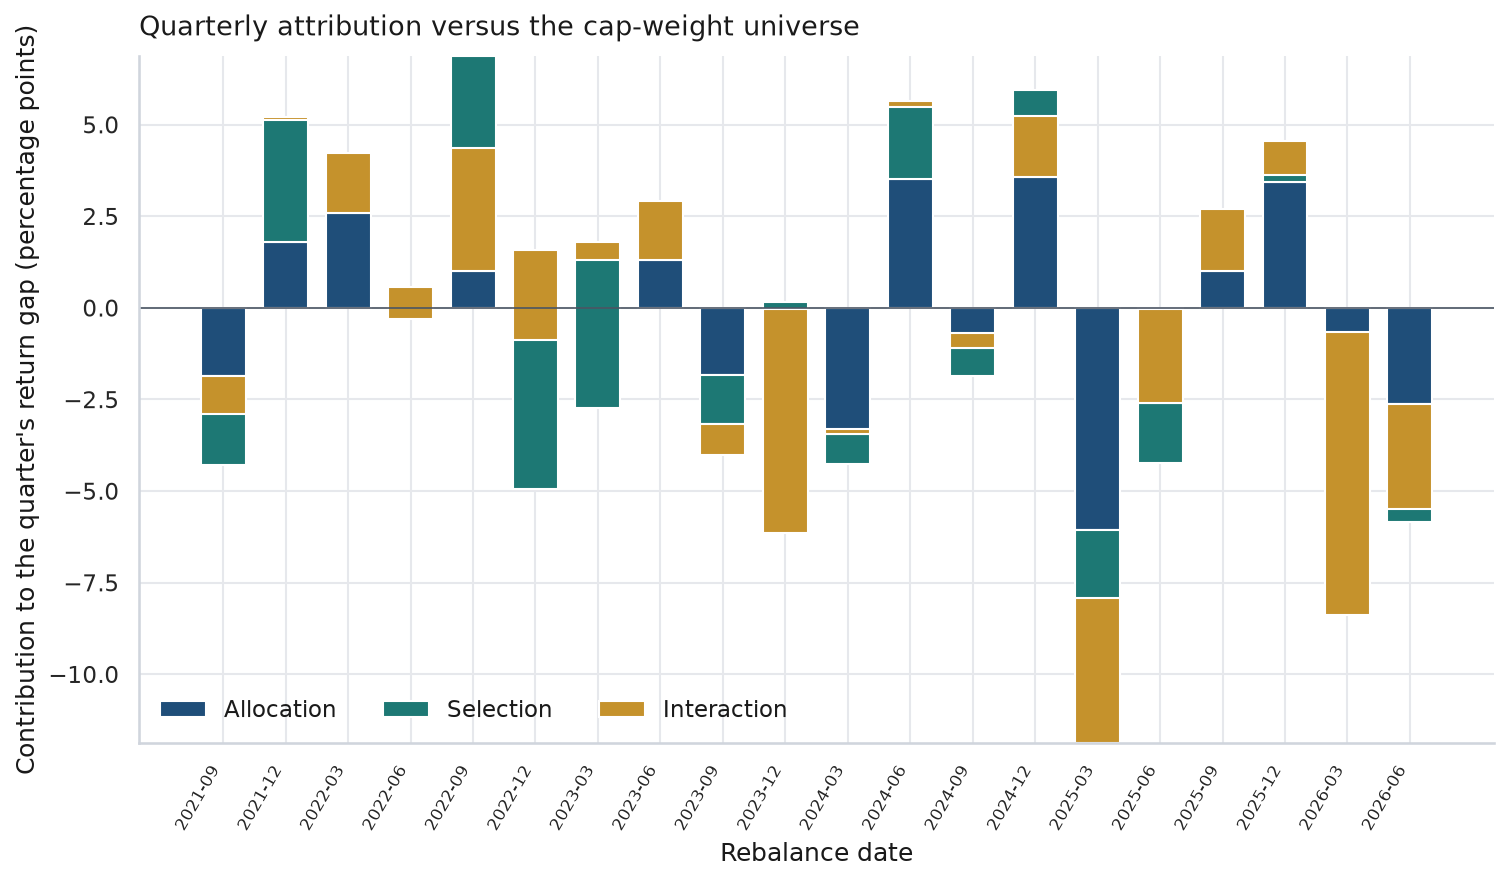

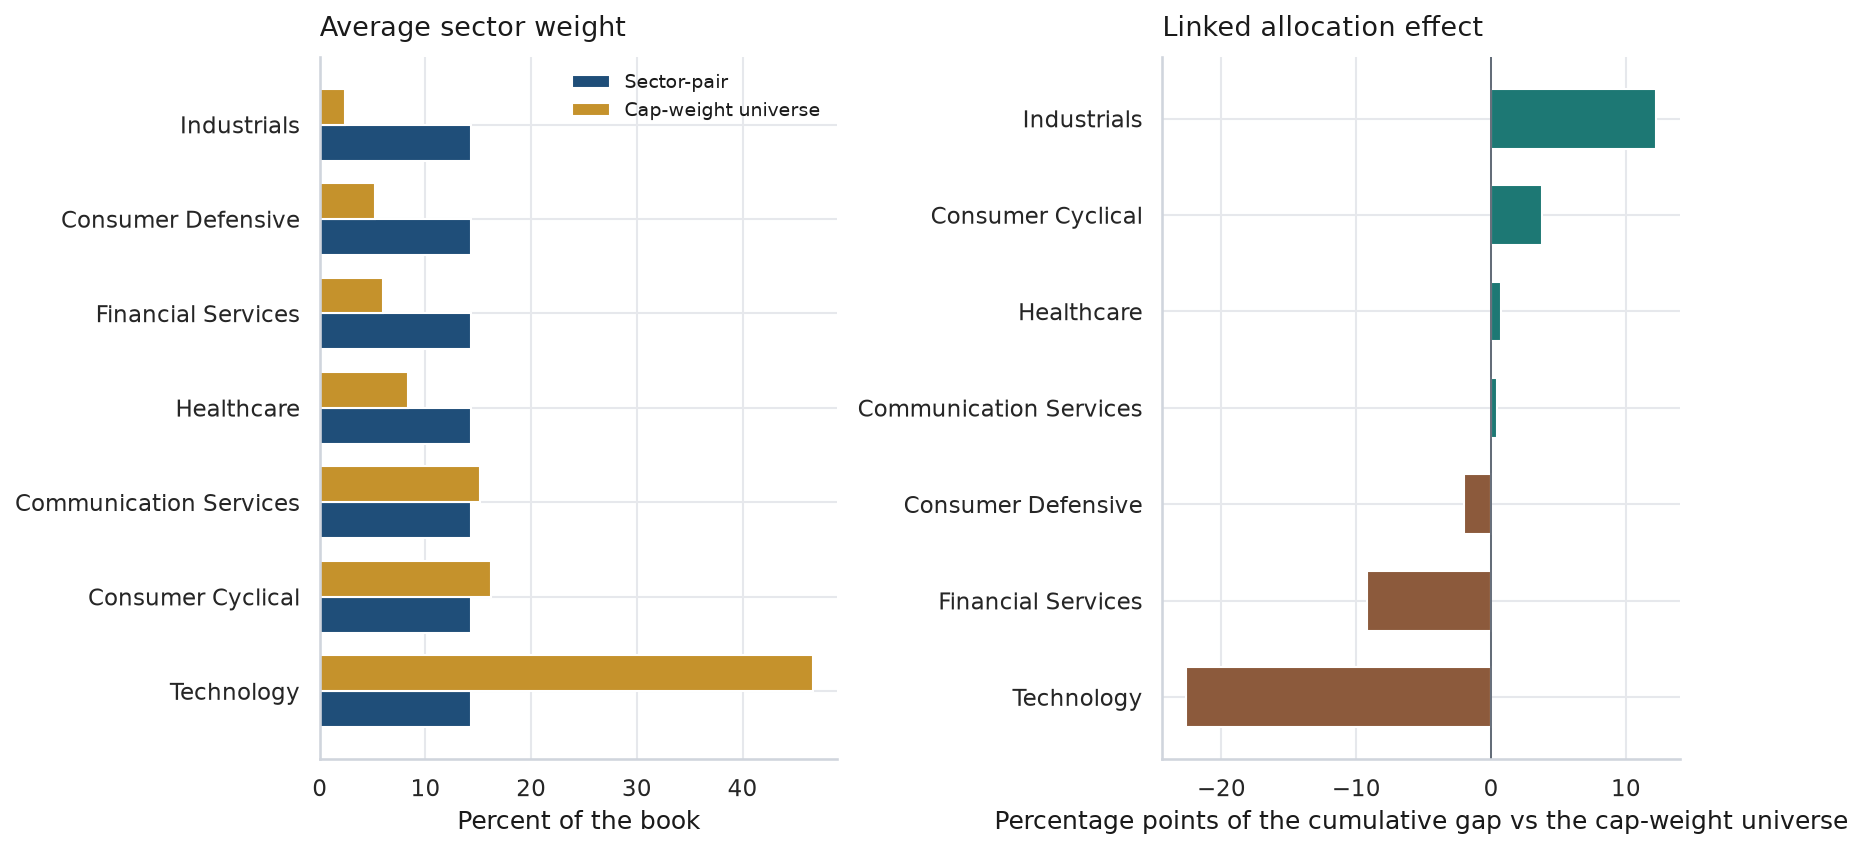

In [8]:
display(Image("images/03_brinson_quarters.png"))
display(Image("images/04_sector_weights.png"))


## 4. Name-level contributions

Each name has one return, so the gap versus the cap-weighted list is a weight gap. Contributions are Carino-linked and sum to the same cumulative gap as the sector table. A name that was never held still has a contribution when the cap-weighted list held it.


In [9]:
raw = attr.run_sql(
    """
    SELECT ticker,
           sector,
           quarters_held,
           avg_active_weight,
           linked_contribution
    FROM contributors
    ORDER BY linked_contribution DESC
    """
)
print("Linked contributions sum to", round(float(raw["linked_contribution"].sum()), 4))
names = raw.copy()
names["avg_active_weight"] = names["avg_active_weight"].round(3)
names["linked_contribution"] = names["linked_contribution"].round(3)
pd.concat([names.head(5), names.tail(5)])


Linked contributions sum to 0.294


,ticker,sector,quarters_held,avg_active_weight,linked_contribution
0,CAT,Industrials,19,0.061,0.166
1,LLY,Healthcare,20,0.050,0.152
2,META,Communication Services,17,0.031,0.086
3,TSLA,Consumer Cyclical,20,0.034,0.082
4,GE,Industrials,12,0.036,0.061
72,COST,Consumer Defensive,7,0.013,-0.038
73,UNH,Healthcare,20,0.053,-0.053
74,MU,Technology,0,-0.006,-0.058
75,AVGO,Technology,0,-0.025,-0.066
76,NVDA,Technology,6,-0.060,-0.211


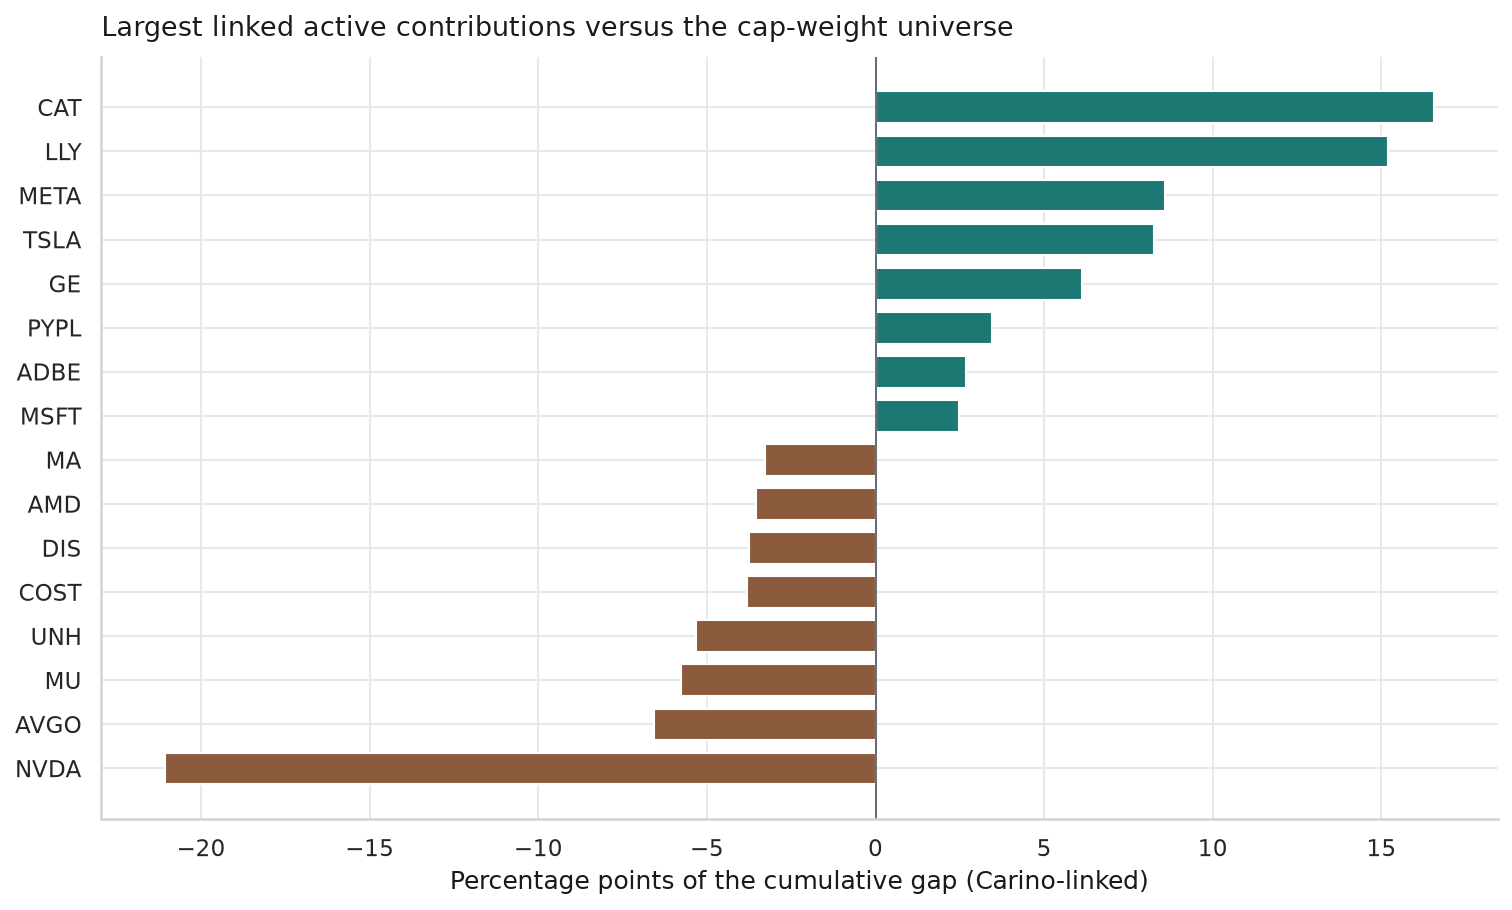

In [10]:
display(Image("images/05_active_contributors.png"))


## 5. Style spreads

The left-hand side of the four-spread regression is the book's monthly return minus IWF. The spreads are IWD minus IWF, IWM minus IWB, MTUM minus SPY, and QUAL minus SPY. They are ETF proxies, not Ken French factors. The fit on the first 30 months is scored on the next 30. The chart's gold line is the four spreads with the intercept removed, so it is not forced to finish on top of the actual gap.


In [11]:
coefs = pd.DataFrame(summary["style_coefficients"])
coefs["coef_monthly"] = coefs["coef_monthly"].round(4)
coefs["se"] = coefs["se"].round(4)
coefs["tstat_descriptive"] = coefs["tstat_descriptive"].round(2)
style = summary["style"]
print(f"Single-index beta on IWF: {style['beta_on_iwf']:.2f}   R² {style['r2_on_iwf']:.2f}")
print(
    "Annualized intercept, monthly intercept times 12, no cash rate: "
    f"{style['alpha_on_iwf_annualized']:.3f}"
)
print(
    "Same regression with BIL subtracted: beta "
    f"{style['beta_excess_bil']:.2f}, annualized intercept {style['alpha_excess_bil_annualized']:.3f}"
)
print(
    f"Four-spread R² in sample {style['r2_full']:.2f}, "
    f"out of sample {style['r2_test']:.2f} "
    f"(train through {style['train_end_inclusive']})"
)
print(
    "Annualized four-spread intercept: "
    f"{style['alpha_annualized']:.3f}"
)
print(
    "Cap-weight universe vs IWF: beta "
    f"{style['cap_beta_on_iwf']:.2f}, R² {style['cap_r2_on_iwf']:.2f}, "
    f"tracking error {style['cap_tracking_error']:.3f}"
)
coefs


Single-index beta on IWF: 0.79   R² 0.85
Annualized intercept, monthly intercept times 12, no cash rate: 0.089
Same regression with BIL subtracted: beta 0.79, annualized intercept 0.081
Four-spread R² in sample 0.52, out of sample 0.42 (train through 2024-03-31)
Annualized four-spread intercept: 0.065
Cap-weight universe vs IWF: beta 0.99, R² 0.98, tracking error 0.029


,term,coef_monthly,se,tstat_descriptive
0,intercept,0.0054,0.0021,2.65
1,value_minus_growth,0.3725,0.0562,6.63
2,small_minus_large,-0.0973,0.0724,-1.34
3,momentum_minus_market,0.0037,0.0590,0.06
4,quality_minus_market,0.3513,0.2056,1.71


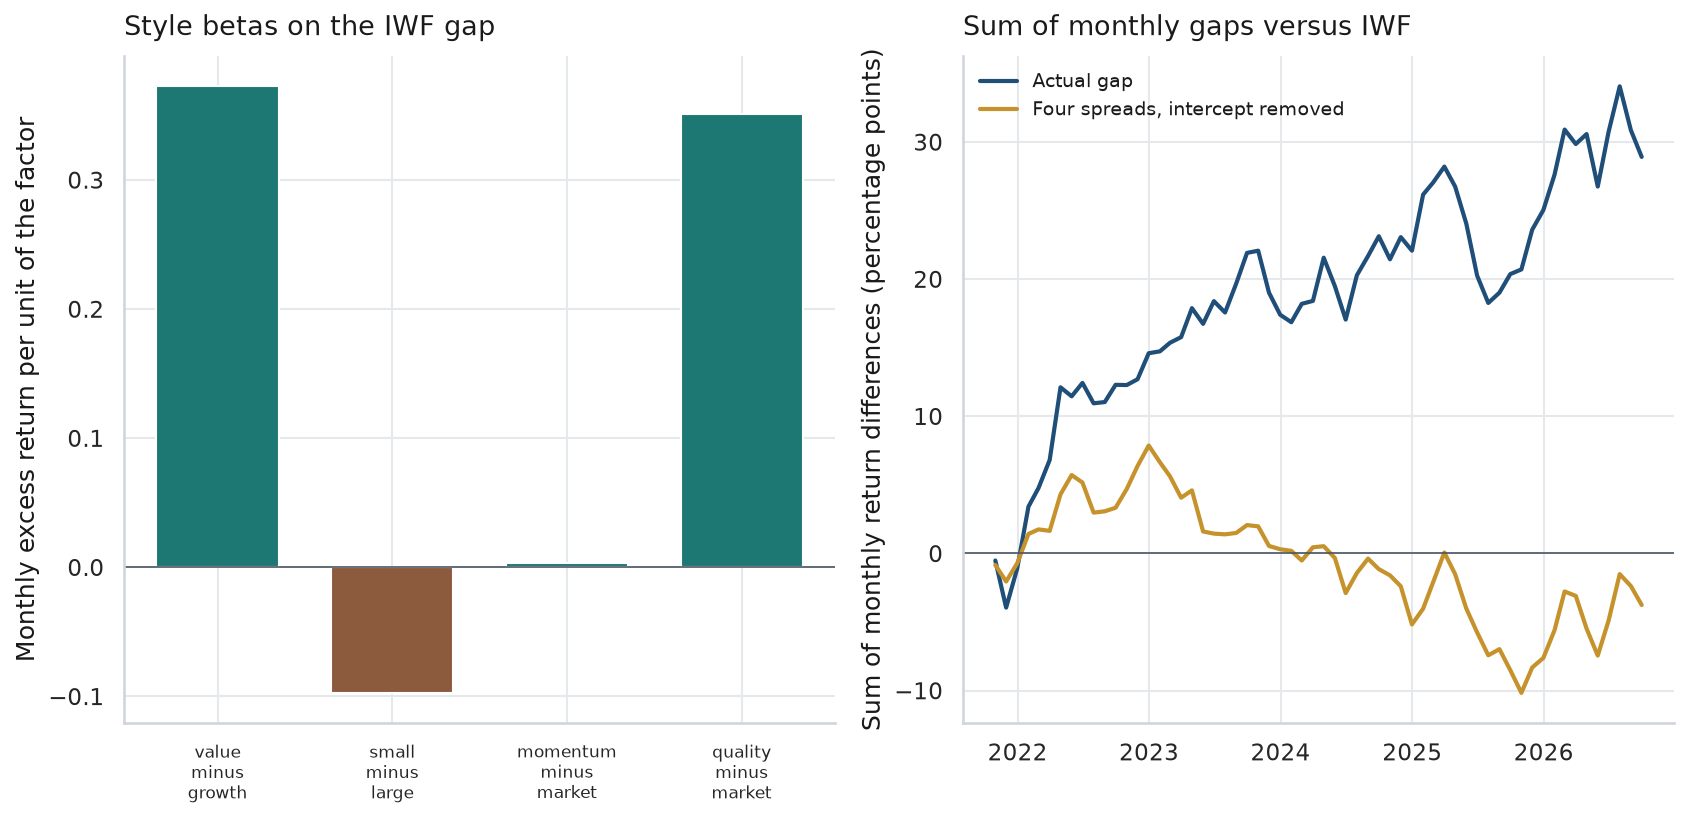

In [12]:
display(Image("images/06_style_fit.png"))


## 6. What to take from the cache

The sector-pair book compounded ahead of IWF, and ahead of a cap-weight of the same 77 names. The second of those leads is an accounting result: allocation subtracted, interaction added more than the total gap, and the largest name effects are an underweight in NVIDIA and overweights in Caterpillar and Eli Lilly. The book won that comparison in 9 of 20 quarters.

The lead versus IWF is partly that accounting and partly the list. The cap-weighted 77 tracks IWF's path and still finishes higher. Survivorship is the first explanation. The style ETFs describe a good share of the month-to-month variation and leave the average gap in the intercept.

Nothing here is a recommendation. Twenty quarters is a short sample. IWF is an ETF, not the index. The market-cap ranks are a point-in-time proxy, checked against Yahoo's own market cap at the end of the file, and they are not official index weights.
